# Collecting the Dataset

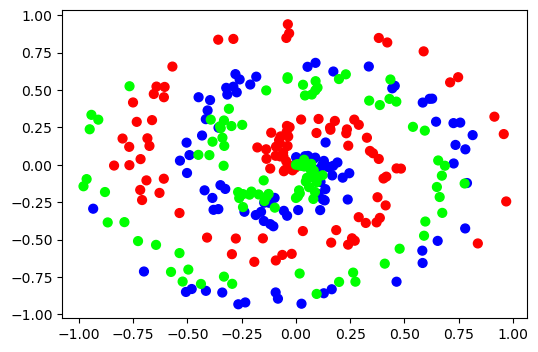

In [22]:
import numpy as np 
import nnfs
import matplotlib.pyplot as plt
nnfs.init()

from nnfs.datasets import spiral_data

x,y = spiral_data(samples = 100, classes=3)
plt.figure(figsize=(6,4))
plt.scatter(x[:,0], x[:,1], c=y, s = 40 , cmap = 'brg')
plt.show()

# Dense Layer Creation

In [33]:
class layer_dense:

    def __init__(self, n_inputs, n_neurons, weight_regularizer_l1=0,  weight_regularizer_l2=0,
                 bias_regularizer_l1 = 0, bias_regularizer_l2 = 0):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.bias_regularizer_l2 = bias_regularizer_l2

    def forward_pass(self, inputs):
        self.inputs = inputs
        self.outputs = np.dot(inputs, self.weights) + self.biases
        return self.outputs
    
    def backprop(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)

        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1 
            self.dweights += self.weight_regularizer_l1 * dL1

        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)
    

# Activation Functions

In [24]:
class Activation_relu:

    def forward(self, inputs):
        self.inputs = inputs
        self.outputs = np.maximum(0, inputs)
    
    def backprop(self, dvalues):
        self.dinputs = dvalues.copy()

        self.dinputs[self.inputs <= 0] = 0

class Activation_softmax:

    def forward(self, inputs):
        self.inputs = inputs
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))

        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)

        self.outputs = probabilities
    
    def backprop(self, dvalues):
        self.dinputs = np.empty_like(dvalues)

        for index, (single_output, single_dvalues) in enumerate(zip(self.outputs, dvalues)):

            single_output = single_output.reshape(-1,1)

            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)

            self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)

# Loss Calculations

In [25]:
class Loss:

    def calculate(self, output, y):
        sample_losses = self.forward(output, y)

        data_loss = np.mean(sample_losses)

        return data_loss
    
    def regularization_loss(self, layer):
        regularization_loss = 0

        if layer.weight_regularizer_l1 > 0:
            regularization_loss += layer.weight_regularizer_l1 * np.sum(np.abs(layer.weights))

        if layer.weight_regularizer_l2 > 0:
            regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights * layer.weights)
        
        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases * layer.biases)

        if layer.bias_regularizer_l1 > 0:
            regularization_loss += layer.bias_regularizer_l1 * np.sum(np.abs(layer.biases))

        return regularization_loss

class Loss_CategoricalCrossEntropy(Loss):

    def forward(self, y_pred, y_true):

        samples = len(y_pred)

        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        if len(y_true.shape) == 1:
            correct_confidence = y_pred_clipped[
                range(samples), y_true
            ]
        
        elif len(y_true.shape) == 2:
            correct_confidence = np.sum(y_true * y_pred_clipped, axis = 1)
        
        negative_los_likelihoods = -np.log(correct_confidence)
        return negative_los_likelihoods
    
    def backprop(self, dvalues, y_true):
        samples = len(dvalues)

        labels = len(dvalues[0])

        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        
        self.dinputs = -y_true/dvalues
        self.dinputs = self.dinputs/samples

class Activation_Softmax_Loss_CategoricalCrossEntropy():
    def __init__(self):
        self.activation = Activation_softmax()
        self.loss = Loss_CategoricalCrossEntropy()

    def forward(self, inputs, y_true):
        self.activation.forward(inputs)
        self.outputs = self.activation.outputs
        return self.loss.calculate(self.outputs, y_true)

    def backprop(self, dvalues, y_true):
        samples = len(y_true)

        #if the y_true is one hot encode then turn them into the sparse 

        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)

        self.dinputs = dvalues.copy()

        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs/samples
        


# Optimizers

### SGD Optimizer with Momentum

In [26]:
class Optimizer_SGD():

    def __init__(self, learning_rate = 1.0, decay=0, momentum = 0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))

    def update_params(self, layer):
        if self.momentum: 

            # now if the layer does not contain the momentum array then we need to create the one with zeros filled
            if not hasattr(layer, 'weight_momentums'):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.biases_momentums = np.zeros_like(layer.biases)

            weight_updates = self.momentum * layer.weight_momentums - self.current_learning_rate*layer.dweights
            bias_updates = self.momentum * layer.biases_momentums - self.current_learning_rate * layer.dbiases

            layer.weight_momentums = weight_updates
            layer.biases_momentums = bias_updates

        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases

        layer.weights += weight_updates
        layer.biases += bias_updates
    
    def post_update_params(self):
        self.iterations +=1

### AdaGrad Optimizer

In [27]:
class Optimizer_AdaGrad():

    def __init__(self, learning_rate=1, decay=0, epsilon=1e-7):
        self.learning_rate = learning_rate
        self.decay = decay
        self.epsilon = epsilon
        self.current_learning_rate = learning_rate
        self.iterations = 0

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1 / (1 + self.decay * self.iterations))
    
    def update_params(self, layer):
        
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.dweights)
            layer.bias_cache = np.zeros_like(layer.dbiases)

        layer.weight_cache += layer.dweights ** 2
        layer.bias_cache += layer.dbiases ** 2

        layer.weights += -self.current_learning_rate * layer.dweights/(np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -self.current_learning_rate * layer.dbiases/(np.sqrt(layer.bias_cache) + self.epsilon)

    def post_update_params(self):
        self.iterations +=1

### RMSProp Optimizer

In [28]:
class Optimizer_RMSprop():

    def __init__(self, learning_rate = 0.001, decay=0, epsilon = 1e-7, rho=0.9):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.rho = rho

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))

    def update_params(self, layer):
         
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.biases_cache = np.zeros_like(layer.biases)

        layer.weight_cache = self.rho * layer.weight_cache + (1 - self.rho) * layer.dweights ** 2
        layer.biases_cache = self.rho * layer.biases_cache + (1 - self.rho) * layer.dbiases ** 2

        layer.weights += -self.current_learning_rate * layer.dweights / (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -self.current_learning_rate * layer.dbiases / (np.sqrt(layer.biases_cache) + self.epsilon)
    
    def post_update_params(self):
        self.iterations +=1

### Adam Optimizer

In [29]:
class Optimizer_ADAM():

    def __init__(self, learning_rate = 0.001, decay=0, epsilon=1e-7, beta_1 = 0.9, beta_2 = 0.999):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.iterations = 0

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1./ (1. + (self.decay * self.iterations)))

    def update_params(self, layer):

        if not hasattr(layer, 'weight_cache'):
            layer.weight_momentum = np.zeros_like(layer.dweights)
            layer.bias_momentum = np.zeros_like(layer.dbiases)

            layer.weight_cache = np.zeros_like(layer.dweights)
            layer.bias_cache = np.zeros_like(layer.dbiases)
        
        layer.weight_momentum = self.beta_1 * layer.weight_momentum + (1 - self.beta_1) * layer.dweights
        layer.bias_momentum = self.beta_1 * layer.bias_momentum + (1 - self.beta_1) * layer.dbiases

        # DOING THE BIAS CORRELATION
        weight_momentum_corrected = layer.weight_momentum / (1 - self.beta_1 ** (self.iterations + 1))
        bias_momentum_corrected = layer.bias_momentum / (1 - self.beta_1 ** (self.iterations + 1))

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * (layer.dweights ** 2)
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * (layer.dbiases ** 2)

        # AGAIN DOING THE BIAS CORRELATION

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1))
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1))

        layer.weights += -self.current_learning_rate * weight_momentum_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon)
        layer.biases += -self.current_learning_rate * bias_momentum_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon)
    
    def post_update_params(self):
        self.iterations += 1


# Training the Model

In [34]:
X, y = spiral_data(samples=100, classes=3)

# Here we are creating a dense layer with 2 inputs and 3 neurons 
# Remember we have already transformed the array in such a way that rows would be inputs and columns would be neurons 

dense_layer_1 = layer_dense(2, 64, weight_regularizer_l2=5e-4, bias_regularizer_l2=5e-4)
Activation_Function_1 = Activation_relu()

dense_layer_2 = layer_dense(64,3)
loss_and_Activation_Softmax = Activation_Softmax_Loss_CategoricalCrossEntropy()

# use the optimizer
# optimizer = Optimizer_SGD(decay=1e-3, momentum=0.9)
# optimizer = Optimizer_AdaGrad(decay=1e-4)
# optimizer = Optimizer_RMSprop(learning_rate=0.02, decay=1e-4, rho=0.999)
optimizer = Optimizer_ADAM(learning_rate=0.02, decay=5e-7)
loss_list = []
epochs_list = []
accuracy_list = []

for epoch in range(10001):

    #perfoming a forward pass through the layer 1
    dense_layer_1.forward_pass(X)

    #giving the dense_layer_1 ouput as a input to the activation function 1 which is a relu function
    Activation_Function_1.forward(dense_layer_1.outputs)

    #taking the output of the activation function 1 and relaying it as input to the dense layer 2
    dense_layer_2.forward_pass(Activation_Function_1.outputs)

    #together perfoming the loss and softmax activation together
    data_loss = loss_and_Activation_Softmax.forward(dense_layer_2.outputs, y)
    regularization_loss = loss_and_Activation_Softmax.loss.regularization_loss(dense_layer_1) + loss_and_Activation_Softmax.loss.regularization_loss(dense_layer_2)
    
    loss = data_loss + regularization_loss

    predictions = np.argmax(loss_and_Activation_Softmax.outputs, axis=1)

    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)

    accuracy = np.mean(predictions == y)

    if epoch%50 == 0:
        loss_list.append(loss)
        epochs_list.append(epoch)
        accuracy_list.append(accuracy)
        print(f'epoch: {epoch}, ' + f'acc: {accuracy: .3f}, ' + f'loss: {loss: .3f}, ' + f'lr: {optimizer.current_learning_rate}')

    # now the crazy part continues which is doing the backward pass

    loss_and_Activation_Softmax.backprop(loss_and_Activation_Softmax.outputs, y)
    dense_layer_2.backprop(loss_and_Activation_Softmax.dinputs)
    Activation_Function_1.backprop(dense_layer_2.dinputs)
    dense_layer_1.backprop(Activation_Function_1.dinputs)

    optimizer.pre_update_params()
    optimizer.update_params(dense_layer_1)
    optimizer.update_params(dense_layer_2)
    optimizer.post_update_params()





epoch: 0, acc:  0.390, loss:  1.099, lr: 0.02
epoch: 50, acc:  0.530, loss:  1.000, lr: 0.019999510012004704
epoch: 100, acc:  0.687, loss:  0.844, lr: 0.019999010049002574
epoch: 150, acc:  0.767, loss:  0.733, lr: 0.019998510110996733
epoch: 200, acc:  0.780, loss:  0.669, lr: 0.019998010197985302
epoch: 250, acc:  0.813, loss:  0.626, lr: 0.019997510309966406
epoch: 300, acc:  0.830, loss:  0.600, lr: 0.019997010446938183
epoch: 350, acc:  0.813, loss:  0.577, lr: 0.01999651060889875
epoch: 400, acc:  0.820, loss:  0.562, lr: 0.01999601079584623
epoch: 450, acc:  0.837, loss:  0.554, lr: 0.019995511007778754
epoch: 500, acc:  0.837, loss:  0.541, lr: 0.01999501124469445
epoch: 550, acc:  0.817, loss:  0.535, lr: 0.019994511506591442
epoch: 600, acc:  0.843, loss:  0.523, lr: 0.01999401179346786
epoch: 650, acc:  0.843, loss:  0.515, lr: 0.019993512105321822
epoch: 700, acc:  0.847, loss:  0.508, lr: 0.01999301244215147
epoch: 750, acc:  0.837, loss:  0.502, lr: 0.01999251280395492
e

### Plotting LOSS vs Accuracy graph

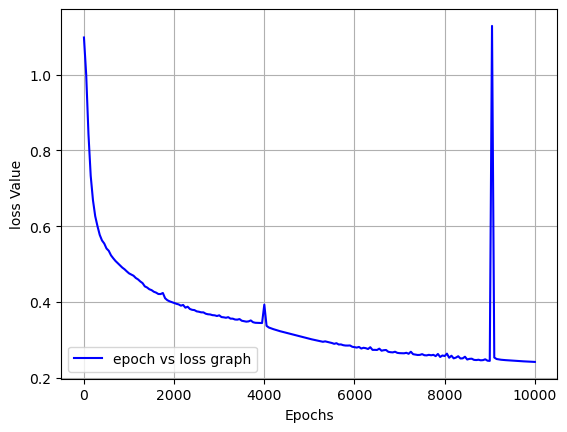

In [35]:
plt.plot(epochs_list, loss_list, '-b', label="epoch vs loss graph")
plt.grid()
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('loss Value')
plt.show()

# Testing on Test Dataset

In [36]:
X_test, y_test = spiral_data(samples=100, classes=3)

dense_layer_1.forward_pass(X_test)

Activation_Function_1.forward(dense_layer_1.outputs)

dense_layer_2.forward_pass(Activation_Function_1.outputs)

loss = loss_and_Activation_Softmax.forward(dense_layer_2.outputs, y_test)

predictions = np.argmax(loss_and_Activation_Softmax.outputs, axis=1)

if len(y.shape) == 2:
    y_test = np.argmax(y_test, axis=1)

accuracy = np.mean(predictions == y_test)

print(f'validation, acc: {accuracy: .3f}, loss: {loss: .3f}')

validation, acc:  0.830, loss:  0.489
